# Feed-Forward Neural Network for Next-Month Affordability Percent Change

Uses current county-month data (`Affordability Metric`, `county_perc_mo`, `mortgage_rate`, `income`, and `avg_housing_price`) plus lag/rolling history to predict the next month percent change in `Affordability Metric`.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import keras
import tensorflow as tf
from tensorflow.keras import layers

tf.keras.utils.set_random_seed(43)


In [ ]:
df = pd.read_csv('../data/processed/final_3d_df_REVISED.csv')
df['date'] = pd.to_datetime({
    'year': df['year'].astype(int),
    'month': df['month'].astype(int),
    'day': 1
})

df = df.sort_values(['fips', 'date']).reset_index(drop=True)

grouped = df.groupby('fips', sort=False)

df['affordability_pct_change'] = grouped['Affordability Metric'].pct_change() * 100
df['next_affordability_metric'] = grouped['Affordability Metric'].shift(-1)
df["target_date"] = grouped["date"].shift(-1)
df['next_affordability_pct_change'] = (
    (df['next_affordability_metric'] / df['Affordability Metric']) - 1
) * 100

target_column = "next_affordability_pct_change"

df[[
    'fips', 
    'date',
    'target_date',
    'Affordability Metric', 
    'next_affordability_metric',
    'affordability_pct_change', 
    target_column,
]].head()


,fips,date,target_date,Affordability Metric,next_affordability_metric,affordability_pct_change,next_affordability_pct_change
0,1001,2006-12-01,2007-01-01,87.701976,91.503678,NaN,4.334797
1,1001,2007-01-01,2007-02-01,91.503678,95.883109,4.334797,4.786070
2,1001,2007-02-01,2007-03-01,95.883109,97.340268,4.786070,1.519725
3,1001,2007-03-01,2007-04-01,97.340268,108.446069,1.519725,11.409256
4,1001,2007-04-01,2007-05-01,108.446069,108.297781,11.409256,-0.136739


In [ ]:
current_features = [
    'Affordability Metric',
    'county_perc_mo',
    'mortgage_rate',
    'income',
    'avg_housing_price',
]
history_features = current_features + ['affordability_pct_change']

grouped = df.groupby('fips', sort=False)

for col in history_features:
    df[f'{col}_prev_mo'] = grouped[col].shift(1)
    df[f'{col}_rolling_3m'] = grouped[col].transform(
        lambda s: s.rolling(window=3, min_periods=1).mean()
    )
    df[f'{col}_rolling_12m'] = grouped[col].transform(
        lambda s: s.rolling(window=12, min_periods=1).mean()
    )

lag_rolling_features = [
    col for col in df.columns
    if col.endswith('_prev_mo') 
    or col.endswith('_rolling_3m') 
    or col.endswith('_rolling_12m')
]

df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12).astype('float32')
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12).astype('float32')

feature_columns = current_features + lag_rolling_features + ['month_sin', 'month_cos']

# Drop rows without housing prices, first-month history, or a next-month target.
model_df = df.dropna(subset=[target_column, "target_date"] + feature_columns).reset_index(drop=True)

# FIPS is categorical. Use embedding ids, not raw FIPS as a numeric feature.
model_df['fips_code'] = pd.Categorical(model_df['fips'].astype(str)).codes.astype('int32')
n_fips = model_df['fips_code'].nunique()

X_feature = model_df[feature_columns].values.astype('float32')
y = model_df[target_column].values.astype('float32')

y_model = y.copy()

# Target sanity check: county_perc_mo is an input feature, not the label.
check_rows = model_df.groupby('fips', sort=False).head(3).copy()
check_rows['manual_next_pct_change'] = (
    (check_rows['next_affordability_metric'] / check_rows['Affordability Metric']) - 1
) * 100
assert target_column == 'next_affordability_pct_change'
assert not np.allclose(y, model_df['county_perc_mo'].values.astype('float32'))

print(f'Target column: {target_column}')
print('county_perc_mo is used as a feature only:', 'county_perc_mo' in feature_columns)
print('county_perc_mo is target:', target_column == 'county_perc_mo')

model_df[[
    'fips', 'date', 'Affordability Metric', 'next_affordability_metric',
    'county_perc_mo', target_column
]].head()


Target column: next_affordability_pct_change
county_perc_mo is used as a feature only: True
county_perc_mo is target: False


,fips,date,Affordability Metric,next_affordability_metric,county_perc_mo,next_affordability_pct_change
0,1001,2007-02-01,95.883109,97.340268,0.312912,1.519725
1,1001,2007-03-01,97.340268,108.446069,0.308228,11.409256
2,1001,2007-04-01,108.446069,108.297781,0.276663,-0.136739
3,1001,2007-05-01,108.297781,118.595218,0.277042,9.508447
4,1001,2007-06-01,118.595218,136.271027,0.252987,14.904318


In [4]:
# Numeric features are scaled after the temporal train/test split to avoid test-period leakage.


In [ ]:
target_year = model_df['target_date'].dt.year

train_mask = target_year <= 2019
val_mask = target_year == 2020
test_mask = target_year > 2020

scaler = StandardScaler()

X_train = scaler.fit_transform(X_feature[train_mask.values]).astype('float32')
X_val = scaler.transform(X_feature[val_mask.values]).astype('float32')
X_test = scaler.transform(X_feature[test_mask.values]).astype('float32')

y_scaler = StandardScaler()

y_train_model = y_scaler.fit_transform(
    y_model[train_mask.values].reshape(-1, 1)
).astype('float32')

y_val_model = y_scaler.transform(
    y_model[val_mask.values].reshape(-1, 1)
).astype('float32')

y_test_model = y_scaler.transform(
    y_model[test_mask.values].reshape(-1, 1)
).astype('float32')

y_train = y[train_mask.values]
y_val = y[val_mask.values]
y_test = y[test_mask.values]

fips_train = model_df.loc[train_mask, 'fips_code'].values.astype('int32')
fips_val = model_df.loc[val_mask, 'fips_code'].values.astype('int32')
fips_test = model_df.loc[test_mask, 'fips_code'].values.astype('int32')

print('Target-year split:')
print('Train target years:', target_year[train_mask].min(), '-', target_year[train_mask].max())
print('Validation target years:', target_year[val_mask].min(), '-', target_year[val_mask].max())
print('Test target years:', target_year[test_mask].min(), '-', target_year[test_mask].max())

print('X train:', X_train.shape)
print('X val:', X_val.shape)
print('X test:', X_test.shape)
print('y train:', y_train.shape)
print('y val:', y_val.shape)
print('y test:', y_test.shape)
print('n_fips:', n_fips)

X train: (256680, 25)
X test: (73647, 25)
y train: (256680,)
y test: (73647,)
n_fips: 1571


In [6]:
input_size = X_train.shape[1]
embedding_size = min(50, max(4, round(np.sqrt(n_fips))))

numeric_input = keras.Input(shape=(input_size,), name='numeric_features')
fips_input = keras.Input(shape=(), dtype='int32', name='fips_code')

fips_embedding = layers.Embedding(n_fips, embedding_size, name='fips_embedding')(fips_input)
fips_embedding = layers.Flatten()(fips_embedding)

x = layers.Concatenate()([numeric_input, fips_embedding])
for units, dropout_rate in [(256, 0.25), (128, 0.20), (64, 0.15), (32, 0.10)]:
    x = layers.Dense(
        units,
        activation='relu',
        kernel_regularizer=keras.regularizers.l2(0.0002)
    )(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout_rate)(x)

output = layers.Dense(1, name='scaled_pct_change')(x)
model = keras.Model(inputs=[numeric_input, fips_input], outputs=output)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0008),
    loss='mse',
    metrics=['mae']
)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ fips_code           │ (None)            │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ fips_embedding      │ (None, 40)        │     62,840 │ fips_code[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ numeric_features    │ (None, 25)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 40)        │          0 │ fips_embedding[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 65)        │          0 │ numeric_features… │
│ (Concatenate)       │                   │            │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │     16,896 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256)       │      1,024 │ dense[0][0]       │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     32,896 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128)       │        512 │ dense_1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 32)        │      2,080 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32)        │        128 │ dense_3[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 32)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ scaled_pct_change   │ (None, 1)         │         33 │ dropout_3[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 124,921 (487.97 KB)

 Trainable params: 123,961 (484.22 KB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
history = model.fit(
    [X_train, fips_train], y_train_model,
    epochs=50,
    batch_size=1024,
    validation_data=([X_val, fips_val], y_val_model),
    verbose=1,
    shuffle=True,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=6,
            restore_best_weights=True
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=3,
            min_lr=0.00001,
            verbose=1
        )
    ]
)

Epoch 1/50



  1/233 ━━━━━━━━━━━━━━━━━━━━ 3:27 893ms/step - loss: 1.6414 - mae: 0.8794


 13/233 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.5045 - mae: 0.8008    


 25/233 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.4900 - mae: 0.7590


 37/233 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.5292 - mae: 0.7310

...


202/233 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5518 - mae: 0.3789


213/233 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5538 - mae: 0.3790


223/233 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5553 - mae: 0.3790


Epoch 15: ReduceLROnPlateau reducing learning rate to 0.00019999999494757503.



233/233 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6208 - mae: 0.3806 - val_loss: 0.2760 - val_mae: 0.2496 - learning_rate: 4.0000e-04


In [ ]:
def regression_metrics(y_true, y_pred):
    mse = mean_squared_error(y_true, y_pred)
    return {
        'MSE': mse,
        'RMSE': np.sqrt(mse),
        'MAE': mean_absolute_error(y_true, y_pred),
        'R2': r2_score(y_true, y_pred)
    }


y_train_pred_scaled = model.predict([X_train, fips_train], verbose=0)
y_val_pred_scaled = model.predict([X_val, fips_val], verbose=0)
y_test_pred_scaled = model.predict([X_test, fips_test], verbose=0)

y_train_pred = y_scaler.inverse_transform(y_train_pred_scaled).reshape(-1)
y_val_pred = y_scaler.inverse_transform(y_val_pred_scaled).reshape(-1)
y_test_pred = y_scaler.inverse_transform(y_test_pred_scaled).reshape(-1)

train_metrics = regression_metrics(y_train, y_train_pred)
val_metrics = regression_metrics(y_val, y_val_pred)
test_metrics = regression_metrics(y_test, y_test_pred)

for name, metrics in [
    ('Train', train_metrics),
    ('Validation', val_metrics),
    ('Test', test_metrics)
]:
    print(f"\n{name} Set:")
    print(f"MSE:  {metrics['MSE']:.6f}")
    print(f"RMSE: {metrics['RMSE']:.6f}")
    print(f"MAE:  {metrics['MAE']:.6f}")
    print(f"R2:   {metrics['R2']:.6f}")

print(f"\nTest prediction std: {np.std(y_test_pred):.6f}")

Train Set:
MSE: 75.798080
RMSE: 8.706209
MAE: 4.455091
R²: 0.609038
Test Set:
MSE: 71.554863
RMSE: 8.459011
MAE: 4.226773
R²: 0.316645
Prediction std: 4.497067


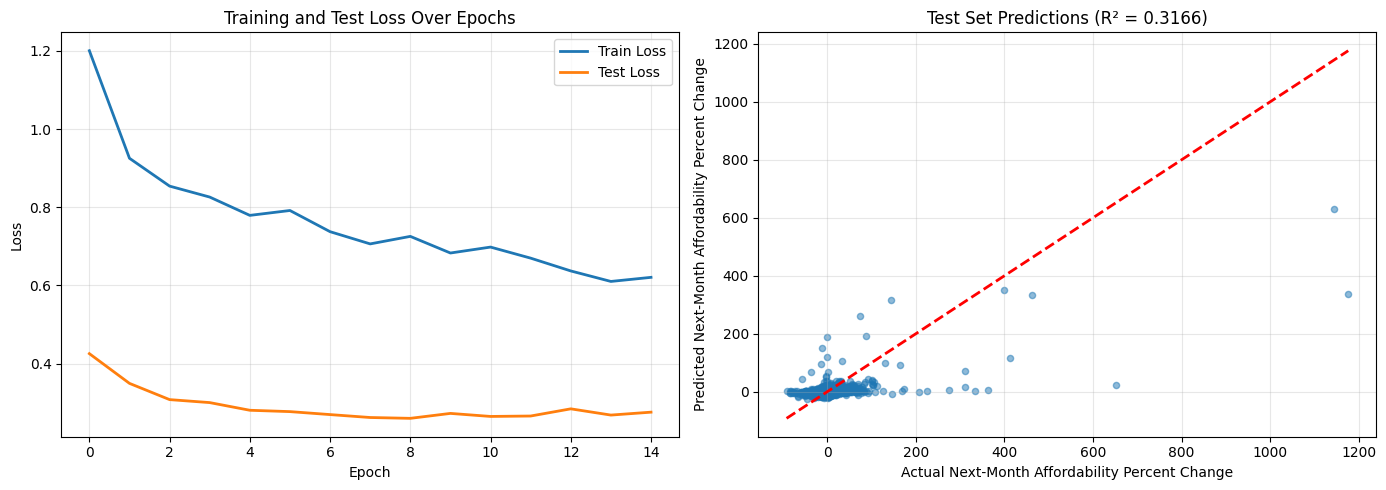

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss Over Epochs')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].scatter(y_test, y_test_pred, alpha=0.5, s=20)
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
axes[1].set_xlabel('Actual Next-Month Affordability Percent Change')
axes[1].set_ylabel('Predicted Next-Month Affordability Percent Change')
axes[1].set_title(f'Test Set Predictions (R2 = {test_metrics["R2"]:.4f})')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

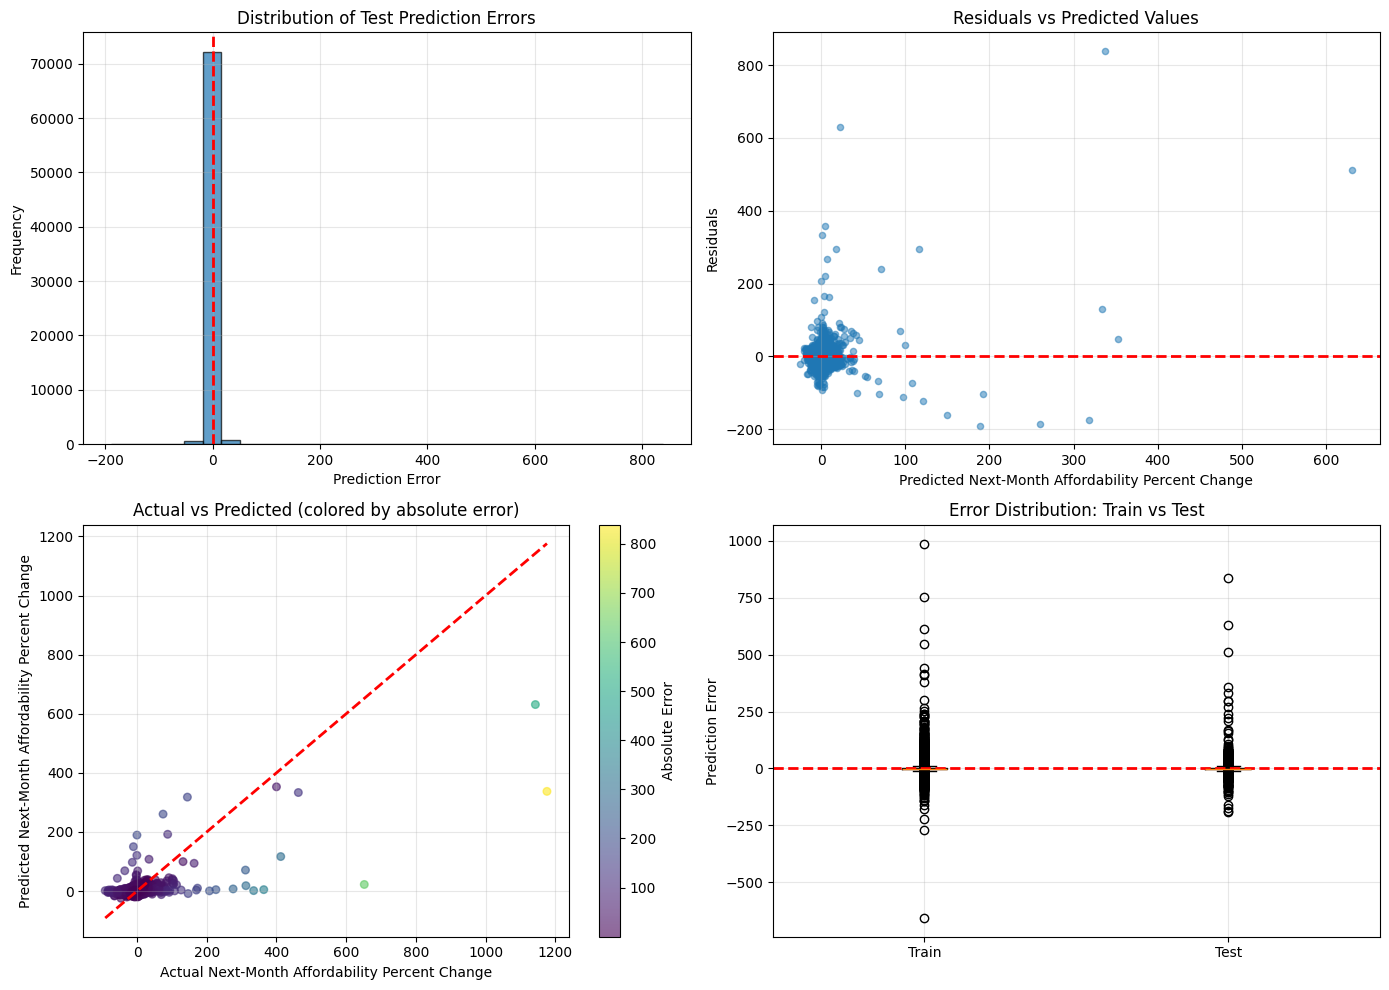


Error Statistics:
Mean Error: -1.275053
Std Error: 8.362363
Min Error: -189.626038
Max Error: 838.621521


In [10]:

# Additional analysis: error distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Residuals plot
residuals = y_test - y_test_pred.flatten()
axes[0, 0].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Prediction Error')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Test Prediction Errors')
axes[0, 0].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[0, 0].grid(True, alpha=0.3)

# Residuals vs predicted
axes[0, 1].scatter(y_test_pred, residuals, alpha=0.5, s=20)
axes[0, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Predicted Next-Month Affordability Percent Change')
axes[0, 1].set_ylabel('Residuals')
axes[0, 1].set_title('Residuals vs Predicted Values')
axes[0, 1].grid(True, alpha=0.3)

# Actual vs Predicted scatter with color gradient by error
errors = np.abs(residuals)
scatter = axes[1, 0].scatter(y_test, y_test_pred, c=errors, cmap='viridis', alpha=0.6, s=30)
axes[1, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2)
axes[1, 0].set_xlabel('Actual Next-Month Affordability Percent Change')
axes[1, 0].set_ylabel('Predicted Next-Month Affordability Percent Change')
axes[1, 0].set_title('Actual vs Predicted (colored by absolute error)')
plt.colorbar(scatter, ax=axes[1, 0], label='Absolute Error')
axes[1, 0].grid(True, alpha=0.3)

# Error by quantile
axes[1, 1].boxplot([y_train - y_train_pred.flatten(), residuals], tick_labels=['Train', 'Test'])
axes[1, 1].set_ylabel('Prediction Error')
axes[1, 1].set_title('Error Distribution: Train vs Test')
axes[1, 1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nError Statistics:")
print(f"Mean Error: {np.mean(residuals):.6f}")
print(f"Std Error: {np.std(residuals):.6f}")
print(f"Min Error: {np.min(residuals):.6f}")
print(f"Max Error: {np.max(residuals):.6f}")
